# Why is the -2 slope homogeneous?

This notebook tests different methods to try and understand the almost homogeneous -2 slope over the globe. Screening of internal tides, impact of edges and XX will be tested.


In [1]:
import traceback
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import netCDF4 as nc
import numpy as np
import xarray as xr
import cmocean
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert,load_swot_l2_unsmoothed 
from swot_analysis.swot_alias_wrapper import process_one_file

## 1. Inputs


In [2]:
# ── Files ──────────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/'
OUTPUT_DIR = None

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_013_344_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_344_mascarene_test.nc'
if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_023_344_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_023_344_mascarene_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_024_456_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_024_456_mascarene_test.nc'
    
if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_013_456_mascarene_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_456_mascarene_test.nc'

if True:
    EXPERT_FILE        = 'SWOT_L2_LR_Expert_013_505_amazon_test.nc'
    EXPERT_FILE_L3     = 'SWOT_L3_LR_Expert_013_505_amazon_test.nc'
    UNSMOOTHED_FILE    = 'SWOT_L2_LR_Unsmoothed_013_505_amazon_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_024_505_amazon_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_024_505_amazon_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_023_561_amazon_test.nc'
    UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_023_561_amazon_test.nc'

if False:
    EXPERT_FILE     = 'SWOT_L2_LR_Expert_024_477_amazon_test.nc'
    #UNSMOOTHED_FILE = 'SWOT_L2_LR_Unsmoothed_013_505_amazon_test.nc'

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 500.0
OVERLAP           = 0.5
MAX_NAN_FRACTION = 0.15
MAX_GAP_FRACTION = 0.1

N_TAPS = 17
MAX_GAP_KM = 75.0
DETREND = 'constant'

# ── Grid parameters ───────────────────────────────────────────────────────
DX1_NATIVE_KM = 0.25
DX2_NATIVE_KM = 0.25

DX1_EXPERT_KM = 2.0
DX2_EXPERT_KM = 2.0

# ── Box size ──────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX, LON_MIN, LON_MAX = -60.0,60.0, 0.0, 360.0
BOX_DEG = 10.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = True   # add internal tide correction (height_cor_xover + internal_tide_hret)
FULL_DIRECT = True


## Compute wavenumber spectra

In [3]:
def run_one_file(filepath):
    #filepath = Path(filepath)
    if OUTPUT_DIR is not None:
        output_file = OUTPUT_DIR / f"{filepath.stem}_alias.pkl"
    else:
        output_file = None
    try:
        result = process_one_file(
            filepath,
            output_file,
            segment_length_km=SEGMENT_LENGTH_KM,
            overlap=OVERLAP,
            max_nan_fraction=MAX_NAN_FRACTION,
            max_gap_fraction=MAX_GAP_FRACTION,
            max_gap_km=MAX_GAP_KM,          # <-- new
            n_taps=N_TAPS,
            dx1_native_km=DX1_NATIVE_KM,
            dx2_native_km=DX2_NATIVE_KM,
            dx1_expert_km=DX1_EXPERT_KM,
            dx2_expert_km=DX2_EXPERT_KM,
            hret=False,
            ssh_var=SSH_VAR,
            full_direct=FULL_DIRECT,
            lat_min = LAT_MIN,
            lat_max = LAT_MAX,
            lon_min = LON_MIN,
            lon_max = LON_MAX,
           # return_counts=True
        )
        if FULL_DIRECT:
            return {
            "file": str(filepath),
            "result": result[0],
            "result_full": result[1],
            "error": None,
            }
        else:
            return {
                "file": str(filepath),
                "result": result,
                "error": None,
            }
    except Exception:
        return {
            "file": str(filepath),
            "result": None,
            "error": traceback.format_exc(),
        }

In [4]:
#Unsmoothed data processing:
entry = run_one_file(DATA_DIR+UNSMOOTHED_FILE)

all_segments = {
    "left": [],
    "right": [],
}

result = entry["result"]
for swath in ("left", "right"):
    all_segments[swath].extend(result[swath])

print(f'left : {len(all_segments["left"])} segments')
print(f'right: {len(all_segments["right"])} segments')

left : 43 segments
right: 44 segments


In [5]:
from swot_analysis.swot_alias_spectra import segments_to_dataset
ds_segments_unsmoothed = segments_to_dataset(all_segments["left"] + all_segments["right"])
print(f'segments: {ds_segments_unsmoothed.segment.size}')

segments: 87


In [6]:
center_latitudes = ds_segments_unsmoothed.lat_mean.values
#center_latitudes[len(all_segments["left"]):]

### Expert processing

In [7]:
def process_one_file_ex(filepath, ssh_var, hret,
                      segment_length_km, overlap, max_gap_fraction, detrend,
                      lat_min, lat_max, lon_min, lon_max, swh_var,
                      cross_track_integrated, left_center_latitudes, right_center_latitudes, max_nan_fraction_2d=0.15):
    """
    Dask worker task: load one Expert granule, compute spectra, filter to
    region of interest, return (granule_stem, list[SegmentSpectrum], wavenumber).
    On any error returns (filepath, error_string, None) with a full traceback
    so the cause is immediately visible in the gather cell.
    """
    import numpy as np
    import xarray as xr
    import traceback as _tb
    from swot_analysis import load_swot_l2_expert
    from swot_analysis import compute_pass_spectra
    from pathlib import Path

    try:
        data = load_swot_l2_expert(filepath, ssh_var=ssh_var, HRET=hret, swh_var=swh_var)
    except Exception:
        return (filepath, f'load error:\n{_tb.format_exc()}', None)

    try:
        result = compute_pass_spectra(
        ssha=data['ssha'],
        latitude=data['latitude'],
        longitude=data['longitude'],
        cross_track_distance=data['cross_track_distance'],
        segment_length_km=segment_length_km,
        overlap=overlap,
        max_gap_fraction=max_gap_fraction,
        detrend=detrend,
        cross_track_integrated=cross_track_integrated,
        left_center_latitudes = left_center_latitudes,
        right_center_latitudes = right_center_latitudes,
        max_nan_fraction_2d=max_nan_fraction_2d,
    )
    except Exception:
        return (filepath, f'spectra error:\n{_tb.format_exc()}', None)

    granule_name = Path(filepath).stem
    kept, wavenumber, wavenumber_2d = [], None, None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        if cross_track_integrated and wavenumber_2d is None and res.wavenumber_2d is not None and res.wavenumber_2d.size:
            wavenumber_2d = res.wavenumber_2d
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                seg._granule = granule_name
                kept.append(seg)
    return (granule_name, kept, wavenumber, wavenumber_2d)
    
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray,
                         wavenumber_2d: Optional[np.ndarray] = None,
                         cross_track_integrated: bool = False) -> xr.Dataset:
    """Pack a flat list of SegmentSpectrum objects into an xarray.Dataset.

    If cross_track_integrated=True, the canonical 'psd'/'wavenumber'
    fields are the 2-D cross-track-integrated estimator (seg.psd_2d /
    wavenumber_2d) rather than the independent-column estimator
    (seg.psd / wavenumber) -- so build_box_dataset() and all downstream
    plotting cells automatically reflect the toggle without changes.
    The unused estimator is NOT retained in this case; rerun with the
    flag off to get the other one.
    """
    if not all_segments:
        raise ValueError('No segments to pack.')

    if cross_track_integrated:
        if wavenumber_2d is None:
            raise ValueError(
                "cross_track_integrated=True but no wavenumber_2d was "
                "provided -- check that process_one_file / the gather "
                "cell propagated it.")
        segs_2d = [s for s in all_segments if s.psd_2d is not None]
        if not segs_2d:
            raise ValueError(
                "cross_track_integrated=True but no segment has a "
                "psd_2d -- every segment failed max_nan_fraction_2d, "
                "or process_one_file/compute_pass_spectra weren't "
                "actually called with cross_track_integrated=True.")
        n_dropped = len(all_segments) - len(segs_2d)
        if n_dropped:
            print(f'segments_to_dataset: dropping {n_dropped}/{len(all_segments)} '
                  f'segments with no psd_2d (failed max_nan_fraction_2d)')
        all_segments = segs_2d
        if wavenumber.size != wavenumber_2d.size:
            psd_2d = np.stack([s.psd_2d for s in all_segments], axis=0)
            psd = np.stack([s.psd[:-1] for s in all_segments], axis=0)
            wavenumber2D_out = wavenumber_2d
            wavenumber_out = wavenumber[:-1]
        else:
            psd_2d = np.stack([s.psd_2d for s in all_segments], axis=0)
            psd = np.stack([s.psd for s in all_segments], axis=0)
            wavenumber2D_out = wavenumber_2d
            wavenumber_out = wavenumber
            
        long_name = 'Cross-track-integrated 2-D SSH(A) PSD'
        data_vars = dict(
        psd=(['segment', 'wavenumber'], psd,
             {'long_name': long_name, 'units': 'm^2 / (cycles/km)'}),
        psd2D=(['segment', 'wavenumber'], psd_2d,
             {'long_name': long_name, 'units': 'm^2 / (cycles/km)'}),
        lat_mean=(['segment'], [s.lat_mean for s in all_segments], {'units': 'degrees_north'}),
        lat_min=(['segment'],  [s.lat_min  for s in all_segments], {'units': 'degrees_north'}),
        lat_max=(['segment'],  [s.lat_max  for s in all_segments], {'units': 'degrees_north'}),
        lon_mean=(['segment'], [s.lon_mean for s in all_segments], {'units': 'degrees_east'}),
        n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
        valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
        swath=(['segment'],   [s.swath    for s in all_segments]),
        granule=(['segment'], [s._granule for s in all_segments]),
        year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
              {'long_name': 'Year of the source SWOT sub-directory'}),
        month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
               {'long_name': 'Month of the source SWOT sub-directory'}),
        )
        coords = dict(
            wavenumber=('wavenumber', wavenumber_out, {'units': 'cycles/km'}),
            #wavenumber2d=('wavenumber2D', wavenumber2D_out, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        )
    else:
        psd = np.stack([s.psd for s in all_segments], axis=0)
        wavenumber_out = wavenumber
        long_name = 'Along-track SSH(A) PSD (averaged over pixels)'

        data_vars = dict(
            psd=(['segment', 'wavenumber'], psd,
                 {'long_name': long_name, 'units': 'm^2 / (cycles/km)'}),
            lat_mean=(['segment'], [s.lat_mean for s in all_segments], {'units': 'degrees_north'}),
            lat_min=(['segment'],  [s.lat_min  for s in all_segments], {'units': 'degrees_north'}),
            lat_max=(['segment'],  [s.lat_max  for s in all_segments], {'units': 'degrees_north'}),
            lon_mean=(['segment'], [s.lon_mean for s in all_segments], {'units': 'degrees_east'}),
            n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
            swath=(['segment'],   [s.swath    for s in all_segments]),
            granule=(['segment'], [s._granule for s in all_segments]),
            year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
                  {'long_name': 'Year of the source SWOT sub-directory'}),
            month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
                   {'long_name': 'Month of the source SWOT sub-directory'}),
        )
        coords = dict(
            wavenumber=('wavenumber', wavenumber_out, {'units': 'cycles/km'}),
            #wavenumber2d=('wavenumber2D', wavenumber2D_out, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        )
    return xr.Dataset(data_vars=data_vars, coords=coords)


def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    #psd2d_all    = ds_segments['psd2D'].values
    wavenumber = ds_segments['wavenumber'].values
    #wavenumber2d = ds_segments['wavenumber2D'].values
    rows_lat, rows_lon, rows_n, rows_psd, rows_psd2d = [], [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        #rows_psd2d.append(np.nanmean(psd2d_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
   # psd2d_stack  = np.stack(rows_psd2d, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            #mean_psd2d=(['box', 'wavenumber'], psd2d_stack[keep],
            #          {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            #wavenumber2D=('wavenumber2D', wavenumber2d, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

def build_box_dataset_un(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    direct_psd_all    = ds_segments['direct_psd'].values
    aliased_psd_all    = ds_segments['aliased_psd'].values
    total_psd_all    = ds_segments['total_psd'].values
    wavenumber = ds_segments['wavenumber'].values

    rows_lat, rows_lon, rows_n, rows_psd_direct, rows_psd_aliased, rows_psd_total = [], [], [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd_direct.append(np.nanmean(direct_psd_all[idxs, :], axis=0))
        rows_psd_aliased.append(np.nanmean(aliased_psd_all[idxs, :], axis=0))
        rows_psd_total.append(np.nanmean(total_psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    direct_psd_stack  = np.stack(rows_psd_direct, axis=0)
    aliased_psd_stack  = np.stack(rows_psd_aliased, axis=0)
    total_psd_stack  = np.stack(rows_psd_total, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            direct_psd=(['box', 'wavenumber'], direct_psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            aliased_psd=(['box', 'wavenumber'], aliased_psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            total_psd=(['box', 'wavenumber'], total_psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            #wavenumber2D=('wavenumber2D', wavenumber2d, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

In [10]:
# Expert:
data_expert    = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=HRET)
#data_expert_l3 = load_swot_l2_expert(DATA_DIR+EXPERT_FILE_L3, ssh_var='ssha_filtered', HRET=HRET)

In [11]:

result_ex = process_one_file_ex(DATA_DIR+EXPERT_FILE, 
                             ssh_var=SSH_VAR,
                             hret=HRET,
                             segment_length_km=SEGMENT_LENGTH_KM,
                             overlap=OVERLAP,
                             max_gap_fraction=MAX_GAP_FRACTION,
                             swh_var=False,
                             detrend=DETREND,
                             lat_min=LAT_MIN, lat_max=LAT_MAX,
                             lon_min=LON_MIN, lon_max=LON_MAX,
                            left_center_latitudes=center_latitudes[:len(all_segments["left"])],
                            right_center_latitudes=center_latitudes[len(all_segments["left"]):],
                            cross_track_integrated=True,
                            )

In [12]:
all_segments_ex, wavenumber, wavenumber_2d, skipped = [], None, None, []
name, payload, wk, wk2 = result_ex          # <-- now 4 values
if isinstance(payload, str):
    skipped.append((name, payload))
else:
    all_segments_ex.extend(payload)
    if wavenumber is None and wk is not None:
         wavenumber = wk
    if wavenumber_2d is None and wk2 is not None:
        wavenumber_2d = wk2

print(f'\nDone. {len(all_segments_ex)} segments retained in region.')
print(f'{len(skipped)} file(s) skipped.')


Done. 86 segments retained in region.
0 file(s) skipped.


In [13]:
if not all_segments_ex:
    raise RuntimeError('No segments retained — check region bounds, '
                        'file pattern, and SSH variable name.')

ds_segments_expert = segments_to_dataset(all_segments_ex, wavenumber,wavenumber_2d, cross_track_integrated = False)
print(f'Segment dataset: {ds_segments_expert.sizes}')

Segment dataset: Frozen({'segment': 86, 'wavenumber': 126})


## 2.Swath visualization

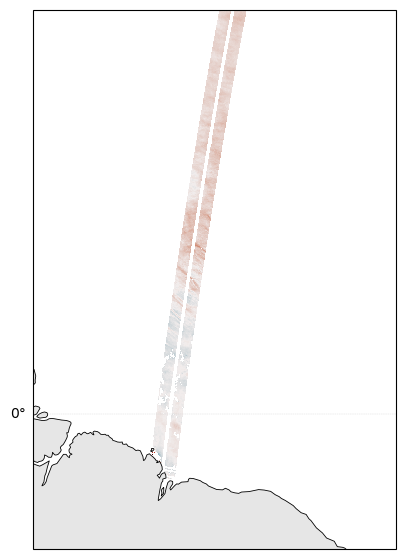

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

fig,ax = plt.subplots(figsize=(7,7),subplot_kw={'projection':ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}

sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], data_expert['ssha'], transform=ccrs.PlateCarree(),
                   cmap=cmocean.cm.balance, vmin = -1, vmax=1)
#ax.scatter(-40,10, transform=ccrs.PlateCarree())
ax.set_extent([-50,-35,-5,15], crs=ccrs.PlateCarree()) #Amazon
#ax.set_extent([40,75,-22,8], crs=ccrs.PlateCarree()) # Mascarene
plt.show()


if False:
    fig,ax = plt.subplots(figsize=(7,7),subplot_kw={'projection':ccrs.Robinson()})
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
        
    gl.top_labels = False
    gl.right_labels = False
    
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    
    gl.xlabel_style = {"size": 10,"color": "black",}
    
    gl.ylabel_style = {"size": 10,"color": "black",}
    
    sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], data_expert['ssha'], transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.balance, vmin = -1, vmax=1)
    #ax.scatter(-40,10, transform=ccrs.PlateCarree())
    #ax.set_extent([-50,-35,-5,15], crs=ccrs.PlateCarree()) #Amazon
    ax.set_extent([60,65,-22,-10], crs=ccrs.PlateCarree()) # Mascarene
    plt.show()

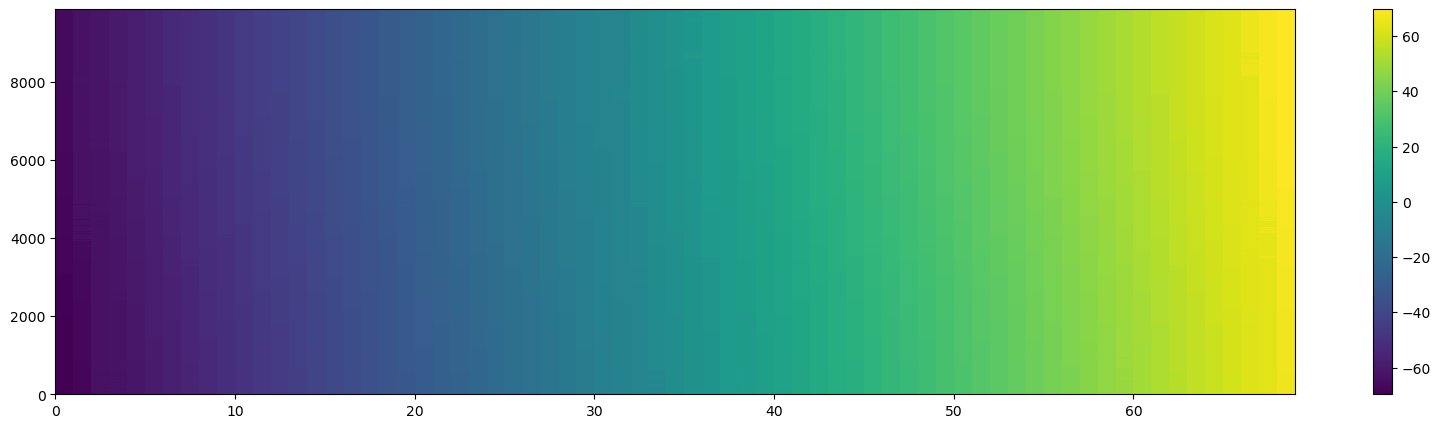

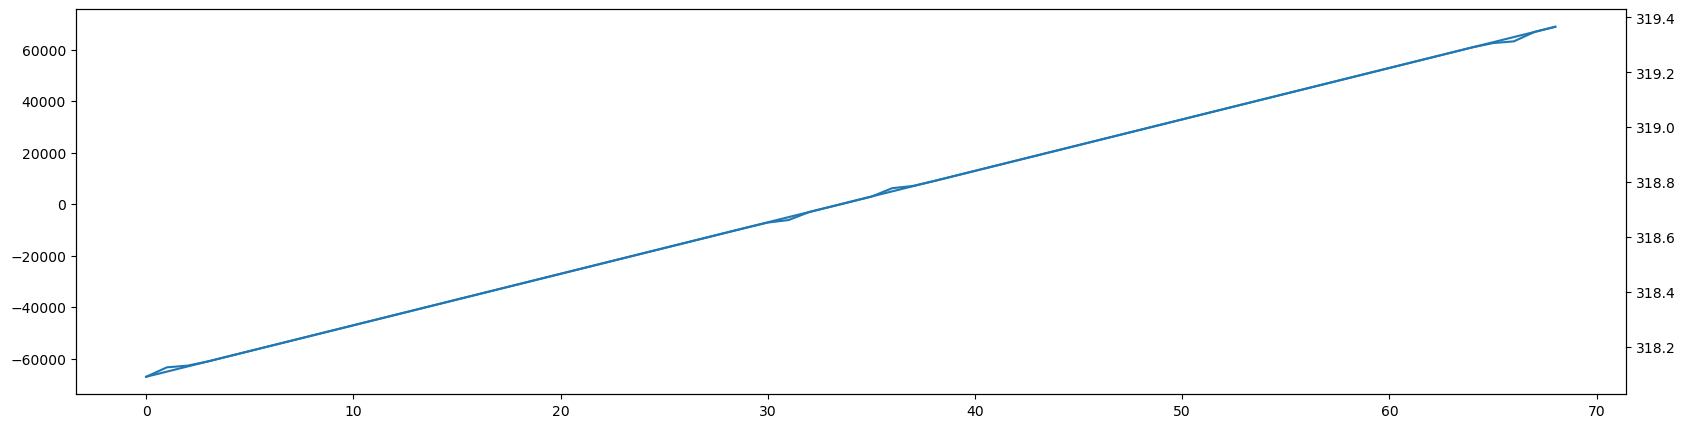

In [15]:
plt.figure(figsize=(20,5))
cs = plt.pcolormesh(data_expert['cross_track_distance']*1e-3)
plt.colorbar(cs)
np.nanmedian(data_expert['cross_track_distance'])

plt.figure(figsize=(20,5))
plt.plot(data_expert['cross_track_distance'][6000,:])
plt.twinx()
plt.plot(data_expert['longitude'][6000,:])

## 4. Diagnostics- spectra

In [16]:
# Flagging
recs_01   = ds_segments_unsmoothed.sel(wavenumber=0.1,method='nearest')
flagged   = ds_segments_unsmoothed.where(recs_01.total_psd<=1e-3)
flagged = flagged.where((flagged.lat_mean<=LAT_MAX) & (flagged.lat_mean>=LAT_MIN))
boxes_un = build_box_dataset_un(flagged, box_deg=0.15)
boxes_ex = build_box_dataset(ds_segments_expert, box_deg=0.15)

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_2179/3467954468.py:220: RuntimeWarning: invalid value encountered in cast
  lat_idx = np.floor(lat / box_deg).astype(int)
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_2179/3467954468.py:221: RuntimeWarning: invalid value encountered in cast
  lon_idx = np.floor(lon / box_deg).astype(int)
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_2179/3467954468.py:235: RuntimeWarning: Mean of empty slice
  rows_psd_direct.append(np.nanmean(direct_psd_all[idxs, :], axis=0))
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_2179/3467954468.py:236: RuntimeWarning: Mean of empty slice
  rows_psd_aliased.append(np.nanmean(aliased_psd_all[idxs, :], axis=0))
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_2179/3467954468.py:237: RuntimeWarning: Mean of empty slice
  rows_psd_total.append(np.nanmean(total_psd_all[idxs, :], axis=0))


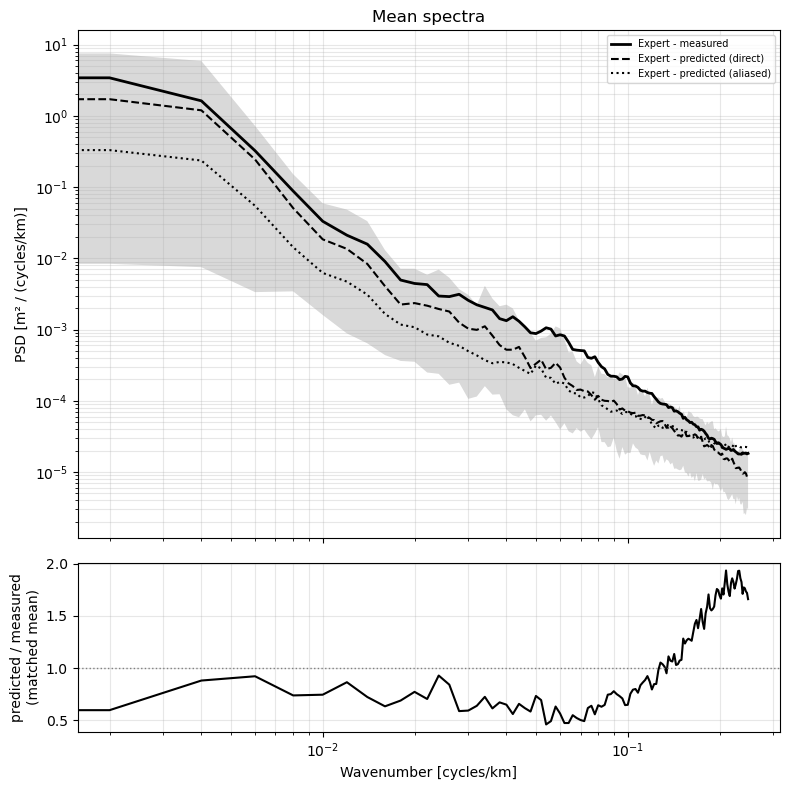

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))
c = 'k'
k = flagged['wavenumber']
direct_median = flagged.direct_psd.mean('segment')#np.nanmean(direct_stack, axis=0)
direct_lo, direct_hi = np.nanpercentile(flagged.direct_psd, [5, 95], axis=0)
aliased_median = flagged.aliased_psd.mean('segment')
aliased_lo, aliased_hi = np.nanpercentile(flagged.aliased_psd, [25, 75], axis=0)
meas_median = ds_segments_expert.psd.mean('segment')
total_median = flagged.total_psd.mean('segment')

ax = axs[0]
ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
try:
    ax.loglog(k, meas_median[:], c=c, lw=2, label=f'Expert - measured ')
    axs[1].semilogx(k, total_median.values / meas_median.values[:], c=c, lw=1.5)
except:
    ax.loglog(k, meas_median[:-1], c=c, lw=2, label=f'Expert - measured ')
    axs[1].semilogx(k, total_median.values / meas_median.values[:-1], c=c, lw=1.5)
ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct)')
ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased)')


axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].set_title(f'Mean spectra')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(1.0, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('predicted / measured\n(matched mean)')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
#axs[1].legend(fontsize=8)
fig.tight_layout()

Text(0.5, 1.0, 'Unsmoothed (250m)')

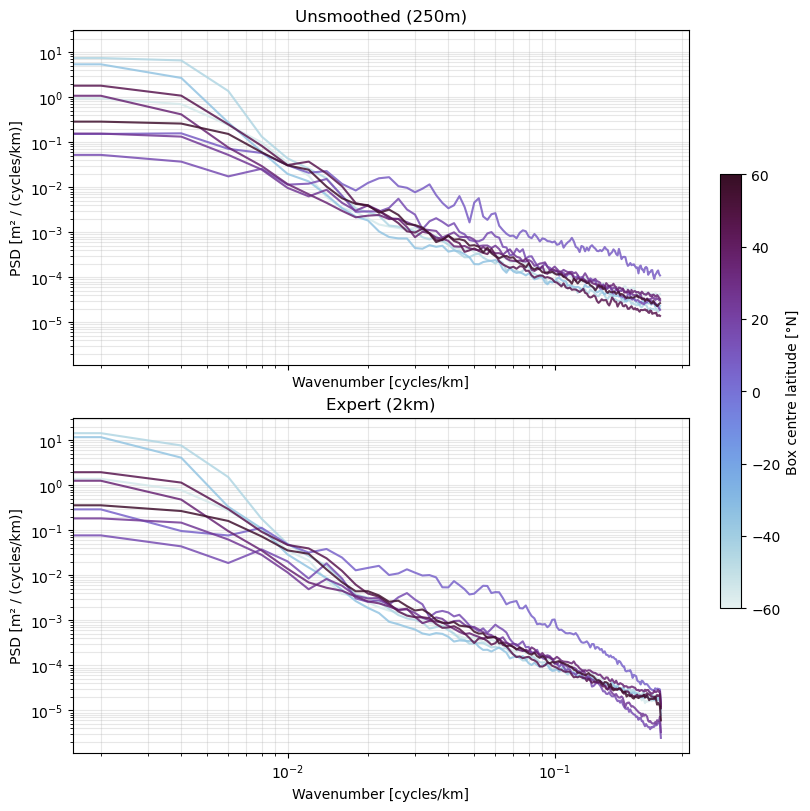

In [18]:
LAT_BIN_EDGES = np.arange(-60, 61, 10)  # adjust to the pass's latitude range
binned_spectra = [flagged.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ds_segments_expert.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ]

fig, axs = plt.subplots(2,1,figsize=(8, 8),sharex=True, sharey=True, constrained_layout=True)
lat_vals = binned_spectra[0]["lat_mean_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap(cmocean.cm.dense)

for i in range(binned_spectra[0].sizes["lat_mean_bins"]):
    lat_box_un = binned_spectra[0].isel(lat_mean_bins = i)
    lat_box_ex = binned_spectra[1].isel(lat_mean_bins = i)
    axs[0].loglog(lat_box_un["wavenumber"], lat_box_un["total_psd"],color=cmap(norm(float(lat_box_un["lat_mean"]))),lw=1.5, alpha=0.85)
    axs[1].loglog(lat_box_ex["wavenumber"], lat_box_ex["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),lw=1.5, alpha=0.85)
axs[0].set_xlabel('')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label="Box centre latitude [°N]",shrink=0.6)
for ax in axs: 
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.set_ylabel("PSD [m² / (cycles/km)]")
    ax.grid(True, which="both", alpha=0.3)
#fig.tight_layout()
axs[1].set_title("Expert (2km)")
axs[0].set_title("Unsmoothed (250m)")

Text(0.5, 1.0, 'Unsmoothed (250m)')

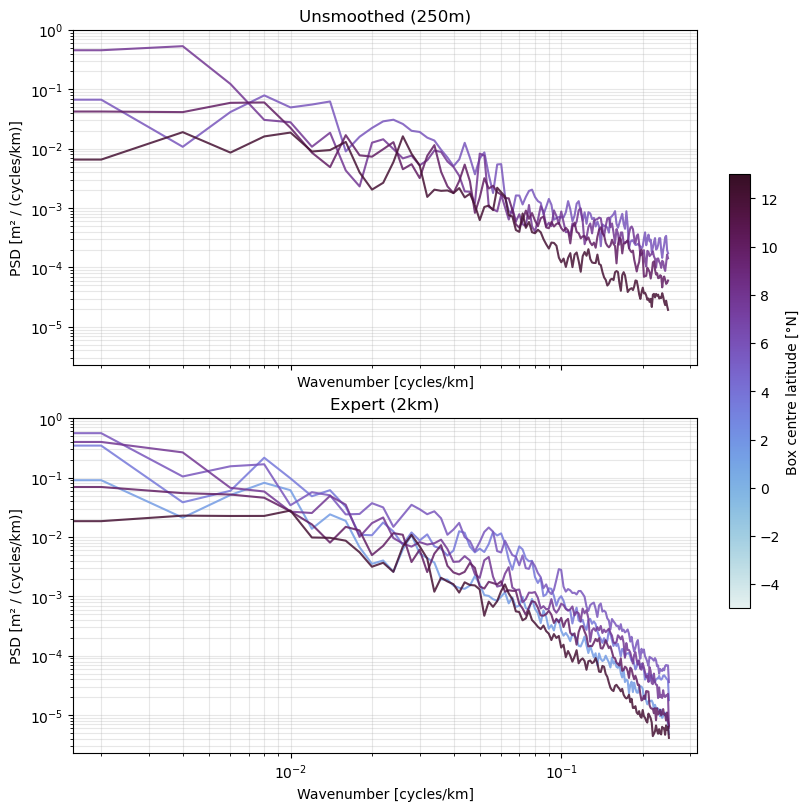

In [19]:
LAT_BIN_EDGES = np.arange(-5, 15, 2)  # adjust to the pass's latitude range
binned_spectra = [flagged.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ds_segments_expert.groupby_bins("lat_mean", LAT_BIN_EDGES).mean(),
                  ]

fig, axs = plt.subplots(2,1,figsize=(8, 8),sharex=True, sharey=True, constrained_layout=True)
lat_vals = binned_spectra[0]["lat_mean_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap(cmocean.cm.dense)

for i in range(binned_spectra[0].sizes["lat_mean_bins"]):
    lat_box_un = binned_spectra[0].isel(lat_mean_bins = i)
    lat_box_ex = binned_spectra[1].isel(lat_mean_bins = i)
    axs[0].loglog(lat_box_un["wavenumber"], lat_box_un["total_psd"],color=cmap(norm(float(lat_box_un["lat_mean"]))),lw=1.5, alpha=0.85)
    axs[1].loglog(lat_box_ex["wavenumber"], lat_box_ex["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),lw=1.5, alpha=0.85)
axs[0].set_xlabel('')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label="Box centre latitude [°N]",shrink=0.6)
for ax in axs: 
    ax.set_xlabel("Wavenumber [cycles/km]")
    ax.set_ylabel("PSD [m² / (cycles/km)]")
    ax.grid(True, which="both", alpha=0.3)
#fig.tight_layout()
axs[1].set_title("Expert (2km)")
axs[0].set_title("Unsmoothed (250m)")

In [20]:
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d


def estimate_separation_scale_adaptive(ds: xr.Dataset,
                                       low_k_band: tuple,
                                       high_k_band: tuple,
                                       psd_var: str = 'mean_psd',
                                        smooth_window: int = 7,
                                        polyorder: int = 2,
                                        search_range: tuple = None,
                                        n_interp: int = 200,
                                        verbose: bool = False) -> xr.Dataset:
    """
    Non-parametric separation scale using an adaptive (per-box) slope
    threshold, calibrated to each spectrum's own mesoscale (low-k, steep)
    and sub-mesoscale (high-k, shallower) plateau slopes, instead of a
    fixed universal reference slope like -2.

    Physical convention: mesoscale (low-k) is expected to be steeper
    (more negative slope) than sub-mesoscale (high-k), consistent with
    the transition from geostrophic/QG turbulence (~ -5 to -11/3) to a
    shallower sub-mesoscale regime (~ -2 to -5/3).

    Parameters
    ----------
    low_k_band, high_k_band : tuple(float, float)
        Wavenumber ranges (cycles/km) used to estimate the plateau slope
        on each side of the transition, well away from the break itself.
    smooth_window, polyorder : SG smoothing parameters for the local-slope
        curve used to locate the crossing.
    search_range : tuple(float, float), optional
        Restrict the crossing search to this wavenumber range (defaults
        to the union of low_k_band and high_k_band).
    """
    wavenumber = ds['wavenumber'].values
    psd_all    = ds[psd_var].values
    n_boxes    = psd_all.shape[0]

    k_valid = wavenumber > 0
    wavenumber = wavenumber[k_valid]
    psd_all = psd_all[:, k_valid]
    log_k_orig = np.log10(wavenumber)

    if smooth_window % 2 == 0:
        smooth_window += 1

    log_k_uniform = np.linspace(log_k_orig.min(), log_k_orig.max(), n_interp)
    dlogk = log_k_uniform[1] - log_k_uniform[0]

    if search_range is None:
        k_lo = low_k_band[0]
        k_hi = high_k_band[1]
    else:
        k_lo, k_hi = search_range
    search_mask = (10**log_k_uniform >= k_lo) & (10**log_k_uniform <= k_hi)

    separation_k    = np.full(n_boxes, np.nan)
    slope_low_all   = np.full(n_boxes, np.nan)
    slope_high_all  = np.full(n_boxes, np.nan)
    threshold_used  = np.full(n_boxes, np.nan)

    for i in range(n_boxes):
        p = psd_all[i]
        valid = np.isfinite(p) & (p > 0)
        if valid.sum() < smooth_window:
            continue

        k = wavenumber[valid]
        logp = np.log10(p[valid])

        # --- Plateau slopes: simple linear fit on RAW (unsmoothed)
        # points within each band, so no window-straddling bias here ---
        low_mask = (k >= low_k_band[0]) & (k <= low_k_band[1])
        high_mask = (k >= high_k_band[0]) & (k <= high_k_band[1])

        if low_mask.sum() < 3 or high_mask.sum() < 3:
            if verbose:
                print(f"Box {i}: not enough points in plateau bands "
                      f"(low={low_mask.sum()}, high={high_mask.sum()}), skipping.")
            continue

        slope_low = np.polyfit(np.log10(k[low_mask]), logp[low_mask], 1)[0]
        slope_high = np.polyfit(np.log10(k[high_mask]), logp[high_mask], 1)[0]
        slope_low_all[i] = slope_low
        slope_high_all[i] = slope_high

        # Adaptive threshold: midpoint between the two plateau slopes
        threshold = 0.5 * (slope_low + slope_high)
        threshold_used[i] = threshold

        # Expect mesoscale (low-k) STEEPER than sub-mesoscale (high-k),
        # i.e. slope_low < slope_high (more negative = steeper).
        if slope_low >= slope_high:
            if verbose:
                print(f"Box {i}: low-k slope ({slope_low:.2f}) not steeper "
                      f"than high-k slope ({slope_high:.2f}) — no clear "
                      f"mesoscale-to-submesoscale steepening-to-shallowing "
                      f"transition, skipping.")
            continue

        # --- Local slope curve via SG, same as before ---
        interp_fn = interp1d(np.log10(k), logp, bounds_error=False, fill_value=np.nan)
        logp_uniform = interp_fn(log_k_uniform)
        valid_u = ~np.isnan(logp_uniform)
        if valid_u.sum() < smooth_window:
            continue

        slope_curve = np.full(n_interp, np.nan)
        win = min(smooth_window, valid_u.sum() if valid_u.sum() % 2 == 1 else valid_u.sum() - 1)
        if win <= polyorder:
            continue
        slope_curve[valid_u] = savgol_filter(logp_uniform[valid_u], window_length=win,
                                              polyorder=polyorder, deriv=1, delta=dlogk)

        mask = search_mask & valid_u
        idxs = np.where(mask)[0]
        if len(idxs) < 2:
            continue

        diff = slope_curve[idxs] - threshold
        sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
        if len(sign_change) == 0:
            if verbose:
                print(f"Box {i}: slope never crosses adaptive threshold "
                      f"{threshold:.2f}.")
            continue

        j = sign_change[0]
        frac = -diff[j] / (diff[j + 1] - diff[j])
        i1, i2 = idxs[j], idxs[j + 1]
        log_k_cross = log_k_uniform[i1] + frac * (log_k_uniform[i2] - log_k_uniform[i1])
        separation_k[i] = 10 ** log_k_cross

    ds_out = ds.copy()
    ds_out['separation_wavenumber'] = (
        ['segment'], separation_k,
        {'long_name': 'Wavenumber of adaptive-threshold slope crossing '
                       '(mesoscale-to-submesoscale transition)',
         'units': 'cycles/km'}
    )
    ds_out['separation_wavelength'] = (
        ['segment'], 1.0 / separation_k,
        {'long_name': 'Separation scale (1/wavenumber)', 'units': 'km'}
    )
    ds_out['slope_low_k'] = (['segment'], slope_low_all,
                              {'long_name': 'Fitted mesoscale (low-k) plateau slope'})
    ds_out['slope_high_k'] = (['segment'], slope_high_all,
                               {'long_name': 'Fitted sub-mesoscale (high-k) plateau slope'})
    ds_out['adaptive_threshold'] = (['segment'], threshold_used,
                                     {'long_name': 'Midpoint slope threshold used per box'})
    return ds_out

In [21]:
ds_sep_adapt_un = estimate_separation_scale_adaptive(
    flagged,
    low_k_band=(1/150, 1/60),   # adjust to your data's low-k regime
    high_k_band=(1/40, 1/10),     # adjust to your data's high-k regime
    psd_var='direct_psd',
    smooth_window=15,
    verbose=False,
)

ds_sep_adapt_ex = estimate_separation_scale_adaptive(
    ds_segments_expert,
    low_k_band=(1/150, 1/60),   # adjust to your data's low-k regime
    high_k_band=(1/50, 1/10),     # adjust to your data's high-k regime
    psd_var='psd',
    smooth_window=15,
    verbose=False,
)

In [22]:
ds_sep_adapt_ex = ds_sep_adapt_ex.sortby('lat_mean')
ds_sep_adapt_un = ds_sep_adapt_un.sortby('lat_mean')

Text(0.5, 0, 'Latitude [°N]')

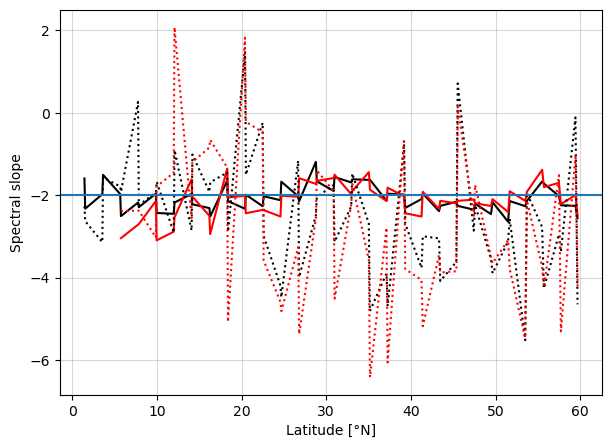

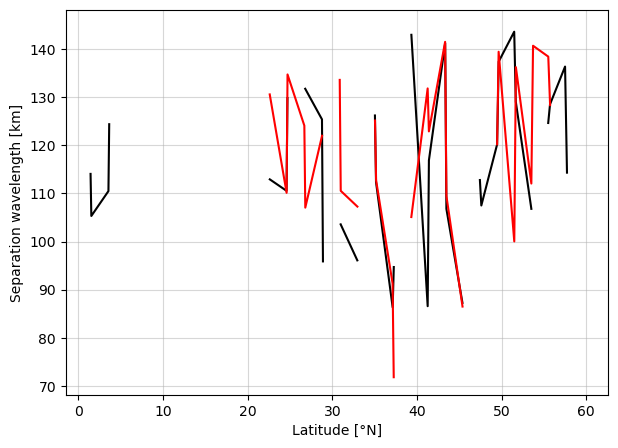

In [23]:
sub_sep_ex = ds_sep_adapt_ex.where(ds_sep_adapt_ex.lat_mean>-5,drop=True)
sub_sep_un = ds_sep_adapt_un.where(ds_sep_adapt_un.lat_mean>-5,drop=True)

fig,ax = plt.subplots(figsize=(7,5))
ax.plot(sub_sep_ex.lat_mean, sub_sep_ex.slope_high_k,c='k',label='expert, high kband')
ax.plot(sub_sep_un.lat_mean, sub_sep_un.slope_high_k,c='r',label='unsmoothed, high kband')
#ax1 = ax.twinx()
ax.plot(sub_sep_ex.lat_mean, sub_sep_ex.slope_low_k,c='k',ls=':', label='expert, low kband')
ax.plot(sub_sep_un.lat_mean, sub_sep_un.slope_low_k,c='r', ls=':', label='unsmoothed, low kband')
ax.axhline(-2)
ax.grid(True, alpha=0.5);
ax.set_ylabel('Spectral slope');ax.set_xlabel('Latitude [°N]')

fig,ax = plt.subplots(figsize=(7,5))
ax.plot(sub_sep_ex.lat_mean, sub_sep_ex.separation_wavelength,c='k',label='expert')
ax.plot(sub_sep_un.lat_mean, sub_sep_un.separation_wavelength,c='r',label='unsmoothed')
ax.grid(True, alpha=0.5);
ax.set_ylabel('Separation wavelength [km]');ax.set_xlabel('Latitude [°N]')

## Screening hret

In [24]:
expert_itide = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=True)
expert_notide = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=False)

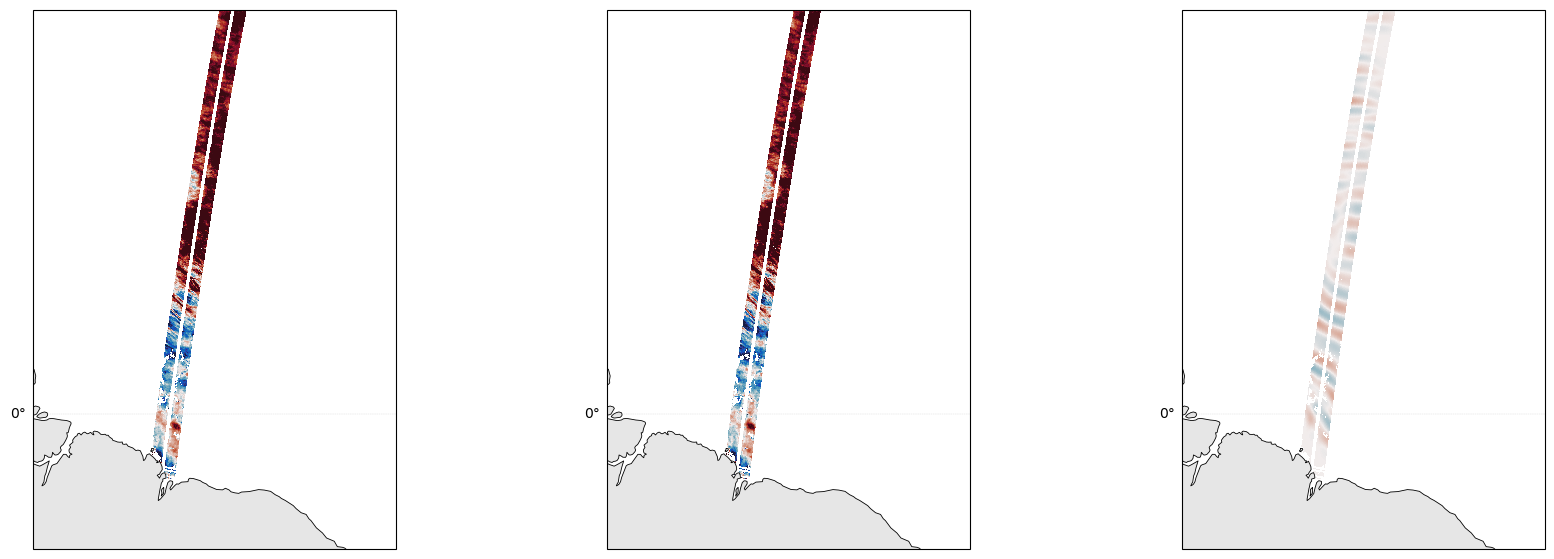

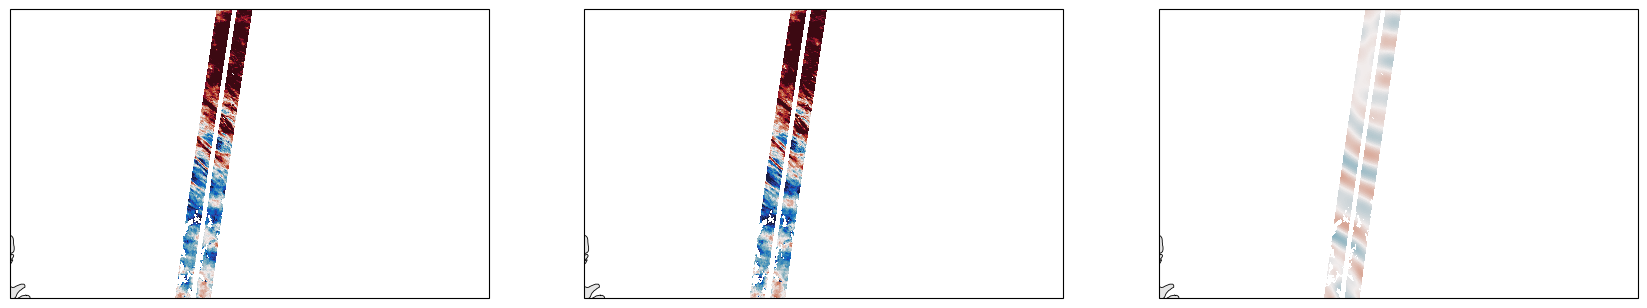

In [25]:
fig,axs = plt.subplots(1,3,figsize=(21,7),subplot_kw={'projection':ccrs.Robinson()})
for ax, ssh_var in zip(axs,[expert_itide['ssha'],expert_notide['ssha'],expert_itide['ssha']-expert_notide['ssha']]):
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
        
    gl.top_labels = False
    gl.right_labels = False
    
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    
    gl.xlabel_style = {"size": 10,"color": "black",}
    
    gl.ylabel_style = {"size": 10,"color": "black",}
    
    sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], ssh_var, transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.balance, vmin = -1e-1, vmax=1e-1)
    #ax.scatter(-40,10, transform=ccrs.PlateCarree())
    ax.set_extent([-50,-35,-5,15], crs=ccrs.PlateCarree()) #Amazon
#ax.set_extent([40,75,-22,8], crs=ccrs.PlateCarree()) # Mascarene

plt.show()

fig,axs = plt.subplots(1,3,figsize=(21,7),subplot_kw={'projection':ccrs.Robinson()})
for ax, ssh_var in zip(axs,[expert_itide['ssha'],expert_notide['ssha'],expert_itide['ssha']-expert_notide['ssha']]):
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
        
    gl.top_labels = False
    gl.right_labels = False
    
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    
    gl.xlabel_style = {"size": 10,"color": "black",}
    
    gl.ylabel_style = {"size": 10,"color": "black",}
    
    sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], ssh_var, transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.balance, vmin = -1e-1, vmax=1e-1)
    #ax.scatter(-40,10, transform=ccrs.PlateCarree())
    ax.set_extent([-50,-35,-0,8], crs=ccrs.PlateCarree()) #Amazon
#ax.set_extent([40,75,-22,8], crs=ccrs.PlateCarree()) # Mascarene

plt.show()


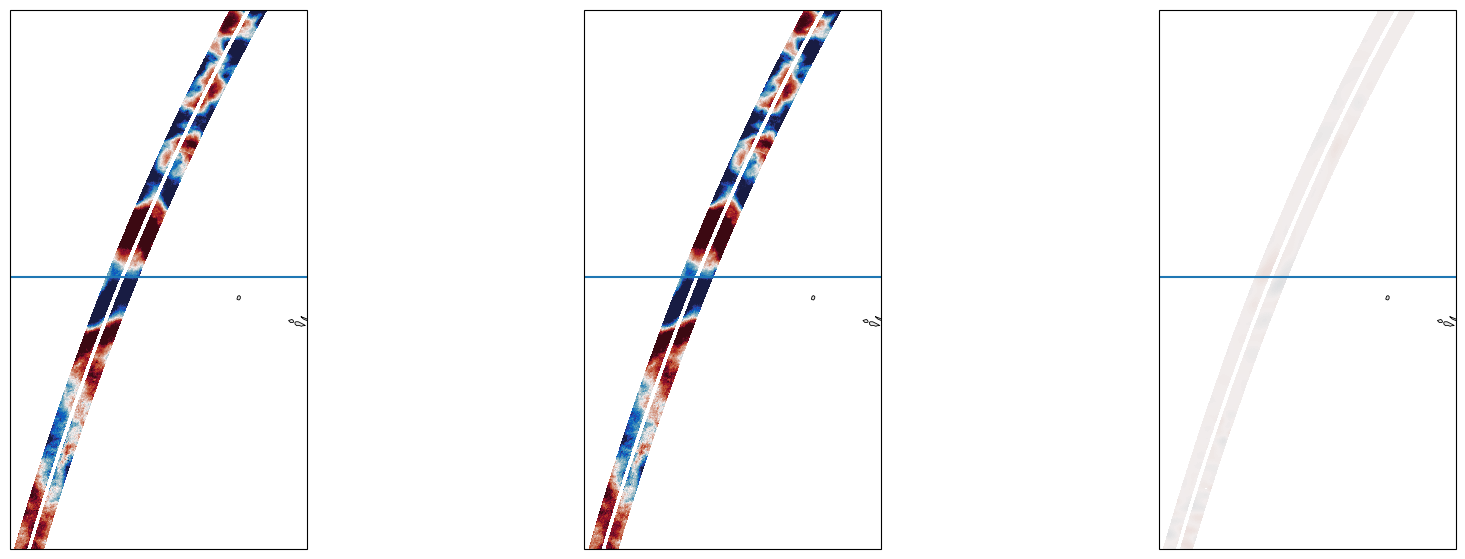

In [26]:
fig,axs = plt.subplots(1,3,figsize=(21,7),subplot_kw={'projection':ccrs.Robinson()})
for ax, ssh_var in zip(axs,[expert_itide['ssha'],expert_notide['ssha'],expert_itide['ssha']-expert_notide['ssha']]):
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
        
    gl.top_labels = False
    gl.right_labels = False
    
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    
    gl.xlabel_style = {"size": 10,"color": "black",}
    
    gl.ylabel_style = {"size": 10,"color": "black",}
    
    sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], ssh_var, transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.balance, vmin = -1e-1, vmax=1e-1)
    
    ax.set_extent([-40,-30,30,50], crs=ccrs.PlateCarree())
    ax.plot([-50,-25],[40,40],transform=ccrs.PlateCarree())
plt.show()


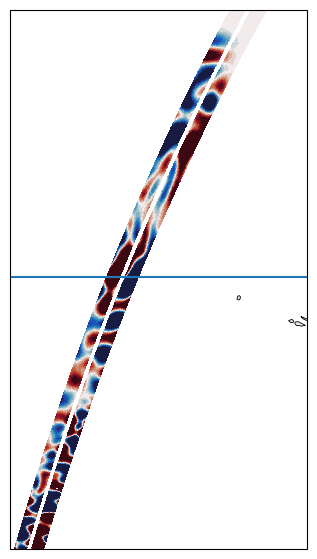

In [27]:
fig,ax= plt.subplots(figsize=(7,7),subplot_kw={'projection':ccrs.Robinson()})
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
        
gl.top_labels = False
gl.right_labels = False
    
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    
gl.xlabel_style = {"size": 10,"color": "black",}
gl.ylabel_style = {"size": 10,"color": "black",}
    
sc = ax.pcolormesh(data_expert['longitude'], data_expert['latitude'], ssh_var, transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.balance, vmin = -1e-3, vmax=1e-3)
    
ax.set_extent([-40,-30,30,50], crs=ccrs.PlateCarree())
ax.plot([-50,-25],[40,40],transform=ccrs.PlateCarree())
plt.show()

In [28]:
result_ex_it = process_one_file_ex(DATA_DIR+EXPERT_FILE, 
                             ssh_var=SSH_VAR,
                             hret=True,
                             segment_length_km=SEGMENT_LENGTH_KM,
                             overlap=OVERLAP,
                             max_gap_fraction=MAX_GAP_FRACTION,
                             swh_var=False,
                             detrend=DETREND,
                             lat_min=LAT_MIN, lat_max=LAT_MAX,
                             lon_min=LON_MIN, lon_max=LON_MAX,
                            left_center_latitudes=center_latitudes[:len(all_segments["left"])],
                            right_center_latitudes=center_latitudes[len(all_segments["left"]):],
                            cross_track_integrated=False,
                            )
result_ex_noit = process_one_file_ex(DATA_DIR+EXPERT_FILE, 
                             ssh_var=SSH_VAR,
                             hret=False,
                             segment_length_km=SEGMENT_LENGTH_KM,
                             overlap=OVERLAP,
                             max_gap_fraction=MAX_GAP_FRACTION,
                             swh_var=False,
                             detrend=DETREND,
                             lat_min=LAT_MIN, lat_max=LAT_MAX,
                             lon_min=LON_MIN, lon_max=LON_MAX,
                            left_center_latitudes=center_latitudes[:len(all_segments["left"])],
                            right_center_latitudes=center_latitudes[len(all_segments["left"]):],
                            cross_track_integrated=False,
                            )

In [29]:
all_segments_ex, wavenumber, wavenumber_2d, skipped = [], None, None, []
name, payload, wk, wk2 = result_ex_it          # <-- now 4 values
if isinstance(payload, str):
    skipped.append((name, payload))
else:
    all_segments_ex.extend(payload)
    if wavenumber is None and wk is not None:
         wavenumber = wk
    if wavenumber_2d is None and wk2 is not None:
        wavenumber_2d = wk2

print(f'\nDone. {len(all_segments_ex)} segments retained in region.')
print(f'{len(skipped)} file(s) skipped.')
ds_segments_expert_it = segments_to_dataset(all_segments_ex, wavenumber,wavenumber_2d, cross_track_integrated = False)

print(f'Segment dataset: {ds_segments_expert.sizes}')


Done. 86 segments retained in region.
0 file(s) skipped.
Segment dataset: Frozen({'segment': 86, 'wavenumber': 126})


In [30]:
all_segments_ex, wavenumber, wavenumber_2d, skipped = [], None, None, []
name, payload, wk, wk2 = result_ex_noit          # <-- now 4 values
if isinstance(payload, str):
    skipped.append((name, payload))
else:
    all_segments_ex.extend(payload)
    if wavenumber is None and wk is not None:
         wavenumber = wk
    if wavenumber_2d is None and wk2 is not None:
        wavenumber_2d = wk2

print(f'\nDone. {len(all_segments_ex)} segments retained in region.')
print(f'{len(skipped)} file(s) skipped.')
ds_segments_expert_noit = segments_to_dataset(all_segments_ex, wavenumber,wavenumber_2d, cross_track_integrated = False)

print(f'Segment dataset: {ds_segments_expert.sizes}')


Done. 86 segments retained in region.
0 file(s) skipped.
Segment dataset: Frozen({'segment': 86, 'wavenumber': 126})


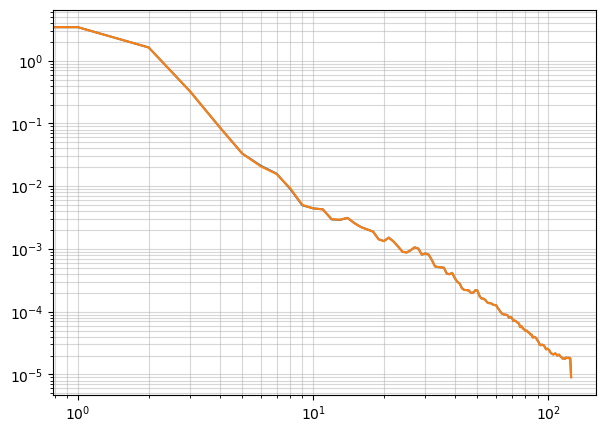

In [31]:
fig,ax = plt.subplots(figsize=(7,5))
ax.loglog(ds_segments_expert_it.mean('segment').psd)
ax.loglog(ds_segments_expert_noit.mean('segment').psd)
ax.grid(True,which='both',alpha=0.5)

Text(0.5, 1.0, 'Expert (2km)')

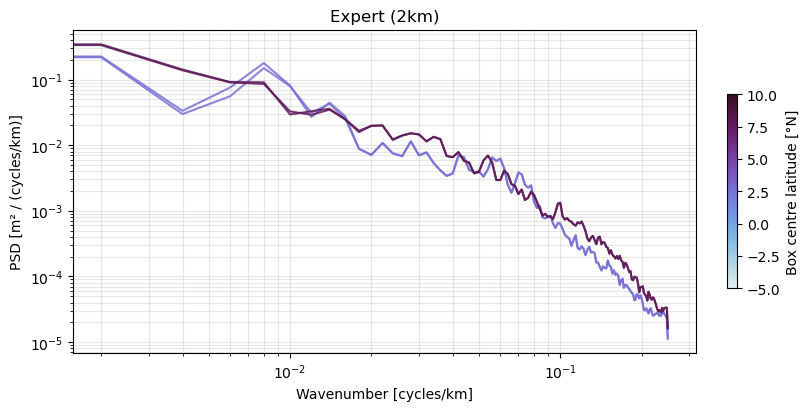

In [35]:
LAT_BIN_EDGES = np.arange(-5, 15, 5)  # adjust to the pass's latitude range
binned_spectra_it = ds_segments_expert_it.groupby_bins("lat_mean", LAT_BIN_EDGES).mean()
binned_spectra_noit = ds_segments_expert_noit.groupby_bins("lat_mean", LAT_BIN_EDGES).mean()

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
lat_vals = binned_spectra_it["lat_mean_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap(cmocean.cm.dense)

for i in range(binned_spectra_it.sizes["lat_mean_bins"]):
    lat_box_ex_it = binned_spectra_it.isel(lat_mean_bins = i)
    lat_box_ex = binned_spectra_noit.isel(lat_mean_bins = i)
    ax.loglog(lat_box_ex["wavenumber"], lat_box_ex["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),lw=1.5, alpha=0.85)
    ax.loglog(lat_box_ex_it["wavenumber"], lat_box_ex_it["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),lw=1.5, alpha=0.85)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]",shrink=0.6)
ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.grid(True, which="both", alpha=0.3)
#fig.tight_layout()
ax.set_title("Expert (2km)")

In [36]:
result = compute_pass_spectra(
        ssha=expert_itide['ssha']-expert_notide['ssha'],
        latitude=expert_itide['latitude'],
        longitude=expert_itide['longitude'],
        cross_track_distance=expert_itide['cross_track_distance'],
        segment_length_km=500.0,
        overlap=0.5,
        max_gap_fraction=MAX_GAP_FRACTION,
        detrend=DETREND,
        cross_track_integrated=False,
        left_center_latitudes = center_latitudes[:len(all_segments["left"])],
        right_center_latitudes=center_latitudes[len(all_segments["left"]):]
        #max_nan_fraction_2d=max_nan_fraction_2d,
    )
granule_name = Path(DATA_DIR+EXPERT_FILE).stem
kept, wavenumber, wavenumber_2d = [], None, None
for res in result.values():
    if res.n_segments_used == 0:
        continue
    if wavenumber is None:
        wavenumber = res.wavenumber
    for seg in res.segments:
        if (-60 <= seg.lat_mean <= 60 and
                    0 <= seg.lon_mean <= 360):
            seg._granule = granule_name
            kept.append(seg)

In [37]:
all_segments_ex, skipped = [], []
all_segments_ex.extend(kept)

ds_segments_expert_hret = segments_to_dataset(all_segments_ex, wavenumber, cross_track_integrated = False)

print(f'Segment dataset: {ds_segments_expert.sizes}')

Segment dataset: Frozen({'segment': 86, 'wavenumber': 126})


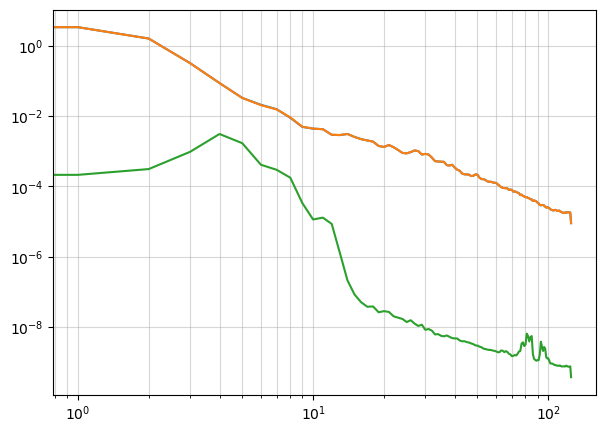

In [38]:
fig,ax = plt.subplots(figsize=(7,5))
ax.loglog(ds_segments_expert_it.mean('segment').psd)
ax.loglog(ds_segments_expert_noit.mean('segment').psd)
ax.loglog(ds_segments_expert_hret.mean('segment').psd)
ax.grid(True,which='both',alpha=0.5)

Text(0.5, 1.0, 'Expert (2km)')

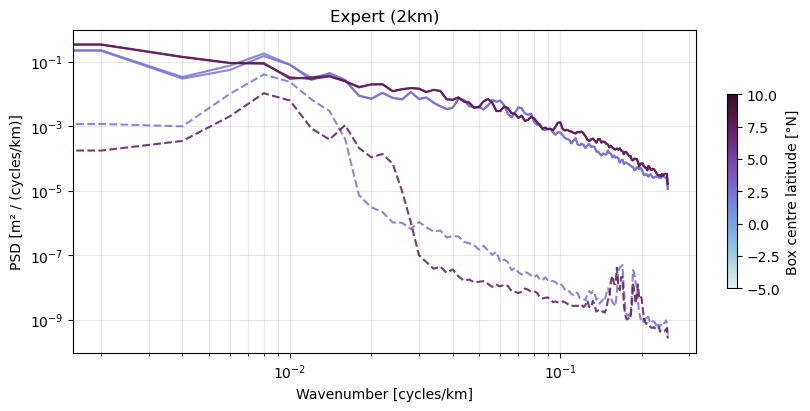

In [40]:
LAT_BIN_EDGES = np.arange(-5, 15, 5)  # adjust to the pass's latitude range
binned_spectra_it = ds_segments_expert_it.groupby_bins("lat_mean", LAT_BIN_EDGES).mean()
binned_spectra_noit = ds_segments_expert_noit.groupby_bins("lat_mean", LAT_BIN_EDGES).mean()
binned_spectra_hret = ds_segments_expert_hret.groupby_bins("lat_mean", LAT_BIN_EDGES).mean()

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
lat_vals = binned_spectra_it["lat_mean_bins"].values
norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap(cmocean.cm.dense)

for i in range(binned_spectra_it.sizes["lat_mean_bins"]):
    lat_box_ex_it = binned_spectra_it.isel(lat_mean_bins = i)
    lat_box_ex = binned_spectra_noit.isel(lat_mean_bins = i)
    lat_box_ex_hret = binned_spectra_hret.isel(lat_mean_bins = i)
    
    ax.loglog(lat_box_ex["wavenumber"], lat_box_ex["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),lw=1.5, alpha=0.85)
    ax.loglog(lat_box_ex_it["wavenumber"], lat_box_ex_it["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),lw=1.5, alpha=0.85)
    ax.loglog(lat_box_ex_hret["wavenumber"], lat_box_ex_hret["psd"],color=cmap(norm(float(lat_box_ex["lat_mean"]))),
              lw=1.5,ls='--', alpha=0.85)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]",shrink=0.6)
ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.grid(True, which="both", alpha=0.3)
#fig.tight_layout()
ax.set_title("Expert (2km)")

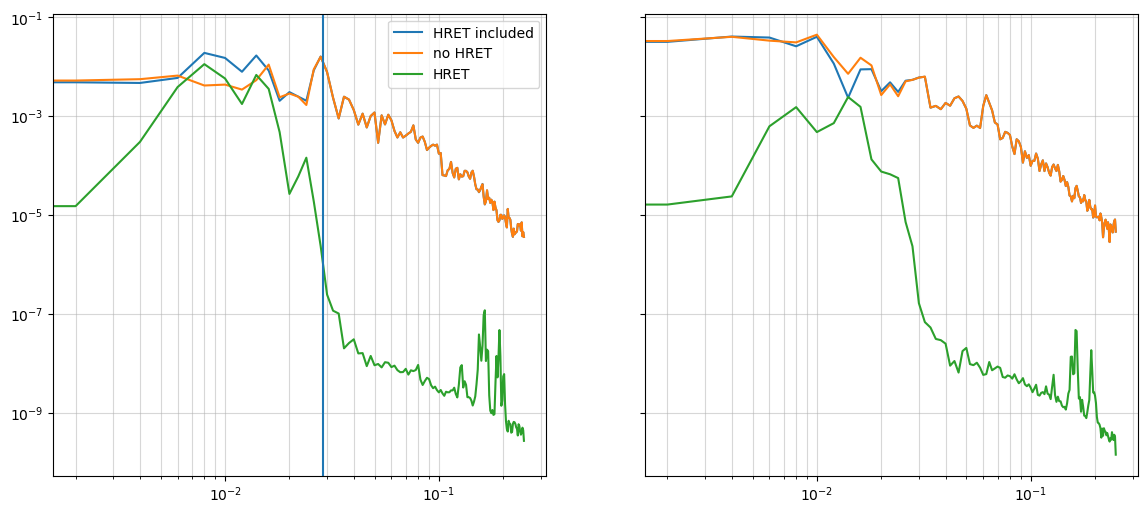

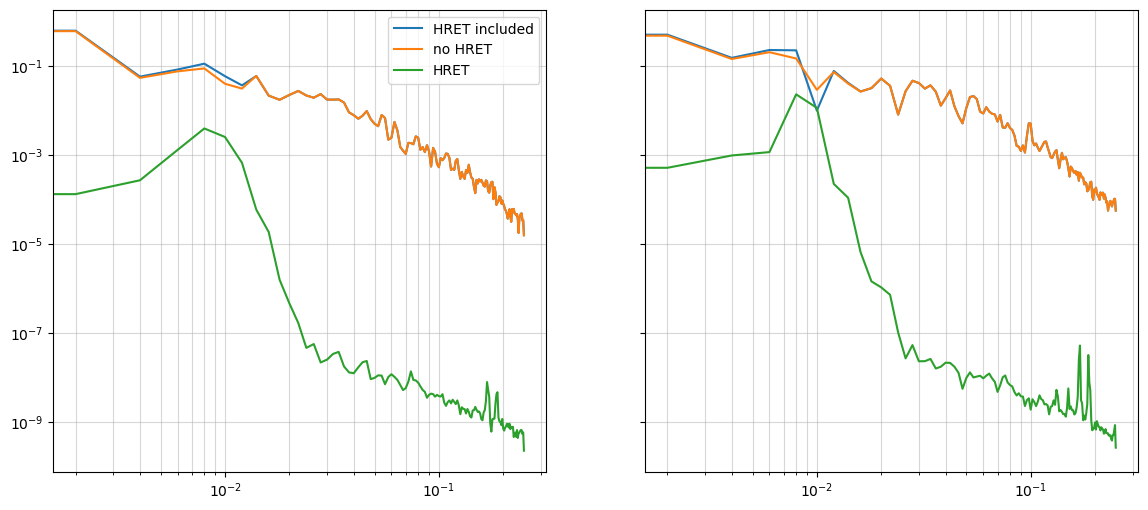

In [41]:
fig,axs = plt.subplots(1,2,figsize=(14,6),sharey=True)
for ax,s in zip(axs,['left','right']):
    sub_it_l = ds_segments_expert_it.where((ds_segments_expert_it.lat_mean>=11)
                                           &(ds_segments_expert_it.lat_mean<=13)
                                           &(ds_segments_expert_it.swath==s),drop=True)
    
    sub_l = ds_segments_expert_noit.where((ds_segments_expert_noit.lat_mean>=11)
                                           &(ds_segments_expert_noit.lat_mean<=13)
                                           &(ds_segments_expert_noit.swath==s),drop=True)
    sub_hret_l = ds_segments_expert_hret.where((ds_segments_expert_hret.lat_mean>=11)
                                           &(ds_segments_expert_hret.lat_mean<=13)
                                           &(ds_segments_expert_hret.swath==s),drop=True)
    ax.loglog(sub_it_l.wavenumber,sub_it_l.mean('segment').psd,label='HRET included')
    ax.loglog(sub_it_l.wavenumber,sub_l.mean('segment').psd, label='no HRET')
    ax.loglog(sub_it_l.wavenumber,sub_hret_l.mean('segment').psd,label='HRET')
    ax.grid(True,which='both',alpha=0.5)
axs[0].legend()
axs[0].axvline(1/35)


fig,axs = plt.subplots(1,2,figsize=(14,6),sharey=True)
for ax,s in zip(axs,['left','right']):
    sub_it_l = ds_segments_expert_it.where((ds_segments_expert_it.lat_mean>=4)
                                           &(ds_segments_expert_it.lat_mean<=6)
                                           &(ds_segments_expert_it.swath==s),drop=True)
    
    sub_l = ds_segments_expert_noit.where((ds_segments_expert_noit.lat_mean>=4)
                                           &(ds_segments_expert_noit.lat_mean<=6)
                                           &(ds_segments_expert_noit.swath==s),drop=True)
    sub_hret_l = ds_segments_expert_hret.where((ds_segments_expert_hret.lat_mean>=4)
                                           &(ds_segments_expert_hret.lat_mean<=6)
                                           &(ds_segments_expert_hret.swath==s),drop=True)
    ax.loglog(sub_it_l.wavenumber,sub_it_l.mean('segment').psd,label='HRET included')
    ax.loglog(sub_it_l.wavenumber,sub_l.mean('segment').psd, label='no HRET')
    ax.loglog(sub_it_l.wavenumber,sub_hret_l.mean('segment').psd,label='HRET')
    #ax.loglog((sub_l+sub_hret_l).mean('segment').psd,label='HRET')
    ax.grid(True,which='both',alpha=0.5)
axs[0].legend()

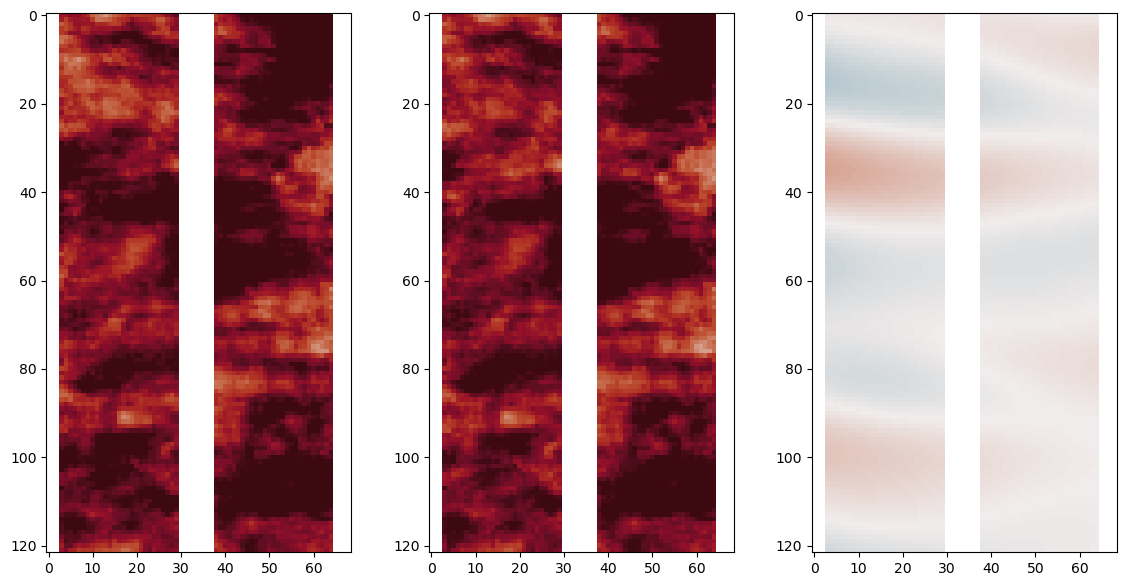

In [42]:
#expert_itide['ssha'][np.where((expert_itide['latitude']>=11)&(expert_itide['latitude']<=13))]
fig,axs = plt.subplots(1,3,figsize=(14,7))

axs[0].imshow(expert_itide['ssha'][np.unique(np.where((expert_itide['latitude']>=11)&(expert_itide['latitude']<=13))[0]),:]
              ,cmap=cmocean.cm.balance,vmax=1e-1,vmin=-1e-1)
axs[1].imshow(expert_notide['ssha'][np.unique(np.where((expert_itide['latitude']>=11)&(expert_itide['latitude']<=13))[0]),:]
              ,cmap=cmocean.cm.balance,vmax=1e-1,vmin=-1e-1)
axs[2].imshow((expert_itide['ssha']-expert_notide['ssha'])[np.unique(np.where((expert_itide['latitude']>=11)&(expert_itide['latitude']<=13))[0]),:]
              ,cmap=cmocean.cm.balance,vmax=1e-1,vmin=-1e-1)

In [43]:
from swot_analysis.swot_alongtrack_spectra import split_left_right_swaths
edges_km = 6.0
edges_pix = int(edges_km/DX1_EXPERT_KM)

def removed_edges(data,edges_pix):
    left_idx = np.where(split_left_right_swaths(data['cross_track_distance'])[0])[0]
    right_idx = np.where(split_left_right_swaths(data['cross_track_distance'])[1])[0]
    id_pix = np.insert(left_idx[edges_pix:-edges_pix],-1,right_idx[edges_pix:-edges_pix])
    result = compute_pass_spectra(
            ssha=data['ssha'][:,id_pix],
            latitude=data['latitude'][:,id_pix],
            longitude=data['longitude'][:,id_pix],
            cross_track_distance=data['cross_track_distance'][:,id_pix],
            segment_length_km=500.0,
            overlap=0.5,
            max_gap_fraction=MAX_GAP_FRACTION,
            detrend=DETREND,
            cross_track_integrated=False,
            left_center_latitudes = center_latitudes[:len(all_segments["left"])],
            right_center_latitudes=center_latitudes[len(all_segments["left"]):]
            #max_nan_fraction_2d=max_nan_fraction_2d,
        )
    granule_name = Path(DATA_DIR+EXPERT_FILE).stem
    kept, wavenumber, wavenumber_2d = [], None, None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        for seg in res.segments:
            if (-60 <= seg.lat_mean <= 60 and
                        0 <= seg.lon_mean <= 360):
                seg._granule = granule_name
                kept.append(seg)
    
    all_segments_ex, skipped = [], []
    all_segments_ex.extend(kept)
    
    ds_segments = segments_to_dataset(all_segments_ex, wavenumber, cross_track_integrated = False)
    return ds_segments
#print(f'Segment dataset: {ds_segments_expert.sizes}')

In [44]:
left_idx = np.where(split_left_right_swaths(expert_itide['cross_track_distance'])[0])[0]
right_idx = np.where(split_left_right_swaths(expert_itide['cross_track_distance'])[1])[0]

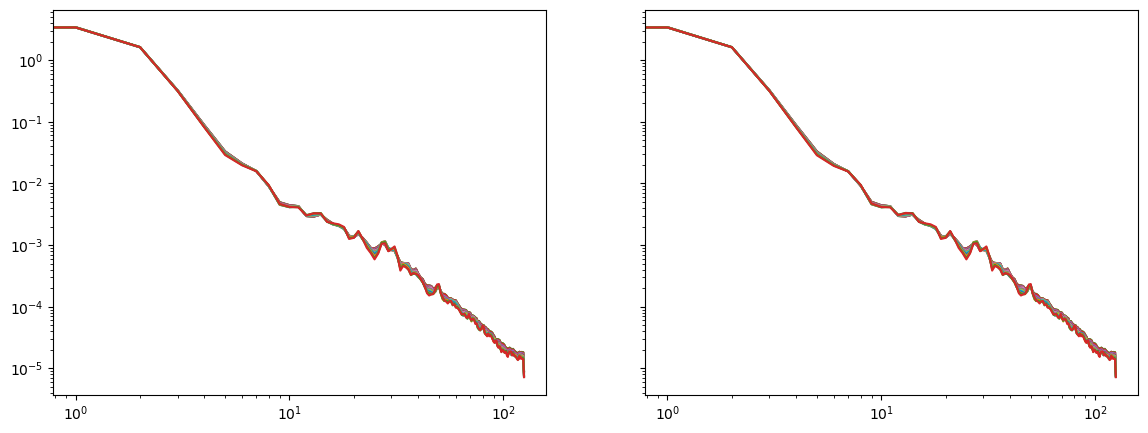

In [45]:
#EDGES_KM = [2.0,10.0,20.0]
EDGES_KM = np.arange(2,30,2)
fig,axs = plt.subplots(1,2,figsize=(14,5),sharey=True,sharex=True)
for edge in EDGES_KM:
    edges_pix = int(edge/DX1_EXPERT_KM)
    _ds_segments = removed_edges(expert_itide,edges_pix)
    axs[0].loglog(_ds_segments.mean('segment').psd)
    _ds_segments = removed_edges(expert_notide,edges_pix)
    axs[1].loglog(_ds_segments.mean('segment').psd)

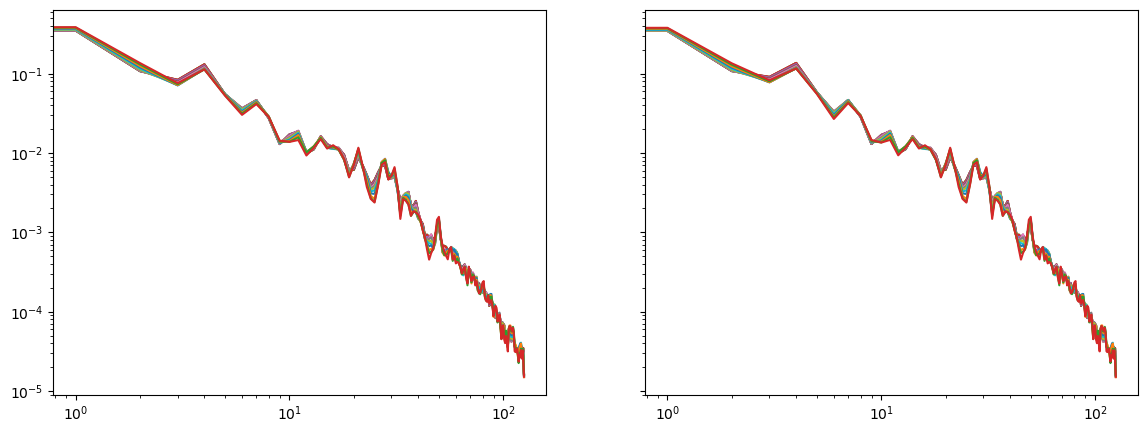

In [46]:
EDGES_KM = np.arange(2,30,2)
fig,axs = plt.subplots(1,2,figsize=(14,5),sharey=True,sharex=True)
for edge in EDGES_KM:
    edges_pix = int(edge/DX1_EXPERT_KM)
    _ds_segments = removed_edges(expert_itide,edges_pix)
    sub_segments = _ds_segments.where((_ds_segments.lat_mean<=8) & (_ds_segments.lat_mean>=0),drop=True)
    axs[0].loglog(sub_segments.mean('segment').psd)
    _ds_segments = removed_edges(expert_notide,edges_pix)
    sub_segments = _ds_segments.where((_ds_segments.lat_mean<=8) & (_ds_segments.lat_mean>=0),drop=True)
    axs[1].loglog(sub_segments.mean('segment').psd)

Text(0.5, 1.0, 'Wavenumber SSHA spectra, no HRET, latitude=12.0°N')

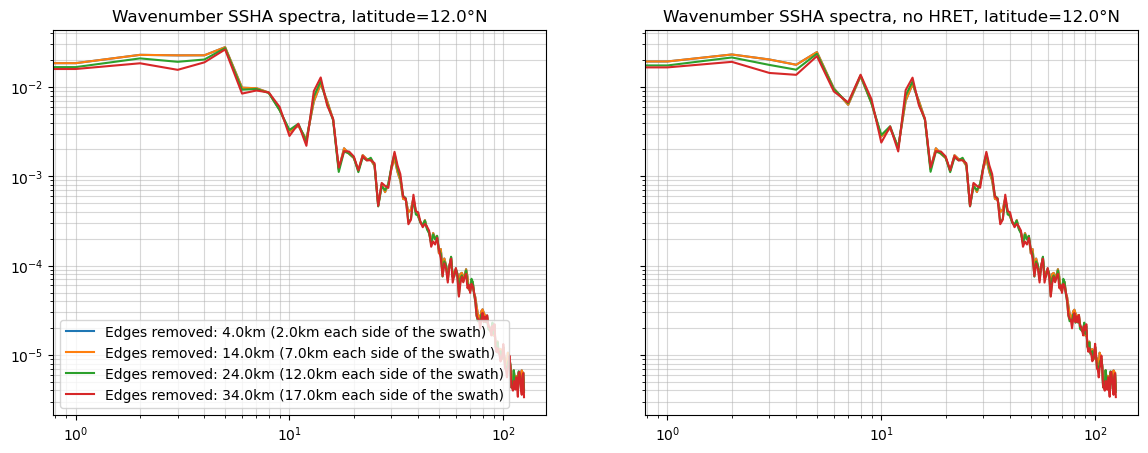

In [47]:
EDGES_KM = np.arange(2,20,5)
fig,axs = plt.subplots(1,2,figsize=(14,5),sharey=True,sharex=True)
for edge in EDGES_KM:
    edges_pix = int(edge/DX1_EXPERT_KM)
    _ds_segments = removed_edges(expert_itide,edges_pix)
    sub_segments_it = _ds_segments.where((_ds_segments.lat_mean<=13) & (_ds_segments.lat_mean>=11),drop=True)
    axs[0].loglog(sub_segments_it.mean('segment').psd,label=f"Edges removed: {2*edge:.1f}km ({edge:.1f}km each side of the swath)")
    _ds_segments = removed_edges(expert_notide,edges_pix)
    sub_segments = _ds_segments.where((_ds_segments.lat_mean<=13) & (_ds_segments.lat_mean>=11),drop=True)
    axs[1].loglog(sub_segments.mean('segment').psd)
    for ax in axs:
        ax.grid(True, which='both',alpha=0.5)
axs[0].legend(loc=3)
axs[0].set_title(f"Wavenumber SSHA spectra, latitude={sub_segments.lat_mean.mean().values:.1f}°N")
axs[1].set_title(f"Wavenumber SSHA spectra, no HRET, latitude={sub_segments.lat_mean.mean().values:.1f}°N")

## identifying spectral peaks

In [48]:
import numpy as np
import xarray as xr
from scipy.signal import find_peaks
from scipy.stats import chi2


def detect_band_spectral_peak(ds_spectra: xr.Dataset,
                               psd_var: str = 'psd',
                               wavelength_band: tuple = (30, 50),
                               background_band: tuple = (15, 100),
                               dof: float = 4.0,
                               confidence: float = 0.95,
                               min_width_points: int = 4,
                               background_fit_min_points: int = 4,
                               verbose: bool = False) -> xr.Dataset:
    """
    Detect a significant spectral peak within a given wavelength band
    (default 30-50 km) for each segment's PSD, by comparing the band
    against a smooth power-law background fit from points just outside
    the band.

    Parameters
    ----------
    ds_spectra : xr.Dataset
        Must have psd_var with dims (segment, wavenumber) and a
        'wavenumber' coordinate in cycles/km.
    psd_var : str
        Name of the PSD variable.
    wavelength_band : tuple(float, float)
        (short, long) wavelength bounds in km to search for a peak,
        e.g. (30, 50).
    background_band : tuple(float, float)
        (short, long) wavelength bounds in km used to estimate the
        smooth background, excluding the peak band itself. Should be
        wider than wavelength_band on both sides, e.g. (15, 100).
    dof : float
        Effective degrees of freedom of each PSD estimate (2x the
        number of independent averages going into it, following the
        usual periodogram convention: dof=2 for a single raw segment
        estimate, larger if segments/cycles were already averaged).
        This sets the significance threshold via the chi-square
        distribution and should be adjusted to match your own
        processing (e.g. Hann-windowed, cross-track- and cycle-averaged
        spectra as in Zhang & Callies 2025 have much higher dof than 2).
    confidence : float
        Confidence level for the peak significance test (e.g. 0.95).
    min_width_points : int
        Minimum number of wavenumber bins inside the band required to
        attempt a peak-width estimate; below this, width is NaN.
    background_fit_min_points : int
        Minimum number of points needed on EACH side (low-k and high-k)
        of the band to fit the background; segments with fewer points
        are skipped.
    verbose : bool
        Print per-segment diagnostics.

    Returns
    -------
    xr.Dataset
        Copy of ds_spectra with added variables (dim 'segment'):
        - 'peak_found' (bool)
        - 'peak_wavelength' (km) -- NaN if not found
        - 'peak_wavenumber' (cycles/km)
        - 'peak_amplitude_ratio' -- PSD / background at the peak
        - 'peak_width' (km) -- NaN if not found or not enough points
        - 'peak_significance_threshold' -- the ratio threshold used
    """
    wavenumber = ds_spectra['wavenumber'].values
    psd_all = ds_spectra[psd_var].values  # (segment, wavenumber)
    n_segments = psd_all.shape[0]

    # Sort by wavenumber ascending (should already be, but be safe)
    order = np.argsort(wavenumber)
    wavenumber = wavenumber[order]
    psd_all = psd_all[:, order]
    log_k = np.log10(wavenumber)

    # Convert wavelength bounds (km) to wavenumber bounds (cycles/km)
    # Careful: short wavelength -> high wavenumber, so bounds flip.
    k_band_lo, k_band_hi = 1.0 / wavelength_band[1], 1.0 / wavelength_band[0]
    k_bg_lo, k_bg_hi = 1.0 / background_band[1], 1.0 / background_band[0]

    band_mask = (wavenumber >= k_band_lo) & (wavenumber <= k_band_hi)
    bg_low_mask = (wavenumber >= k_bg_lo) & (wavenumber < k_band_lo)
    bg_high_mask = (wavenumber > k_band_hi) & (wavenumber <= k_bg_hi)
    bg_fit_mask = bg_low_mask | bg_high_mask

    if band_mask.sum() < 1:
        raise ValueError("No wavenumber bins fall inside wavelength_band; "
                          "check units/bounds against ds_spectra['wavenumber'].")

    # Significance threshold: ratio of observed/expected PSD under H0
    # (pure background, no peak) follows chi2(dof)/dof.
    threshold = chi2.ppf(confidence, dof) / dof

    peak_found = np.zeros(n_segments, dtype=bool)
    peak_wavelength = np.full(n_segments, np.nan)
    peak_wavenumber = np.full(n_segments, np.nan)
    peak_ratio = np.full(n_segments, np.nan)
    peak_width = np.full(n_segments, np.nan)

    for i in range(n_segments):
        p = psd_all[i]
        valid = np.isfinite(p) & (p > 0)

        bg_idx = np.where(bg_fit_mask & valid)[0]
        band_idx = np.where(band_mask & valid)[0]

        if len(np.where(bg_low_mask & valid)[0]) < background_fit_min_points or \
           len(np.where(bg_high_mask & valid)[0]) < background_fit_min_points:
            if verbose:
                print(f"Segment {i}: insufficient background points on "
                      f"both sides, skipping.")
            continue
        if len(band_idx) < 1:
            continue

        # Fit smooth background: log-log linear fit using points OUTSIDE
        # the band only, so the peak itself can't bias its own baseline.
        slope, intercept = np.polyfit(log_k[bg_idx], np.log10(p[bg_idx]), 1)
        background_band_vals = 10 ** (slope * log_k[band_idx] + intercept)

        ratio = p[band_idx] / background_band_vals

        # Find local maxima in the ratio curve within the band.
        # Pad with neighbouring background points so a peak sitting near
        # the band edge can still be recognized as a local max.
        pad_left = np.where(bg_low_mask & valid)[0][-2:] if bg_low_mask.any() else np.array([], dtype=int)
        pad_right = np.where(bg_high_mask & valid)[0][:2] if bg_high_mask.any() else np.array([], dtype=int)
        ext_idx = np.concatenate([pad_left, band_idx, pad_right])
        ext_log_k = log_k[ext_idx]
        ext_bg = 10 ** (slope * ext_log_k + intercept)
        ext_ratio = p[ext_idx] / ext_bg

        peaks_idx, _ = find_peaks(ext_ratio)
        # Keep only peaks that (a) exceed the significance threshold and
        # (b) actually fall within the true band (not in the padding).
        band_start = len(pad_left)
        band_end = band_start + len(band_idx)
        candidate_peaks = [j for j in peaks_idx
                           if ext_ratio[j] > threshold
                           and band_start <= j < band_end]

        if len(candidate_peaks) == 0:
            if verbose:
                print(f"Segment {i}: no significant peak "
                      f"(max ratio in band = {ratio.max():.2f}, "
                      f"threshold = {threshold:.2f}).")
            continue

        # If multiple significant peaks, take the strongest one.
        j_best = max(candidate_peaks, key=lambda j: ext_ratio[j])

        # Sub-bin refinement via parabolic (quadratic) interpolation of
        # log(ratio) vs log(k) around the discrete maximum.
        if 0 < j_best < len(ext_ratio) - 1:
            x0, x1, x2 = ext_log_k[j_best - 1:j_best + 2]
            y0, y1, y2 = np.log10(ext_ratio[j_best - 1:j_best + 2])
            denom = (x0 - x1) * (x0 - x2) * (x1 - x2)
            if denom != 0:
                A = (x2 * (y1 - y0) + x1 * (y0 - y2) + x0 * (y2 - y1)) / denom
                B = (x2**2 * (y0 - y1) + x1**2 * (y2 - y0) + x0**2 * (y1 - y2)) / denom
                if A != 0:
                    log_k_peak = -B / (2 * A)
                    # Only trust the refinement if it stays within the
                    # local bracket; otherwise fall back to the raw bin.
                    if x0 <= log_k_peak <= x2:
                        k_peak = 10 ** log_k_peak
                    else:
                        k_peak = 10 ** ext_log_k[j_best]
                else:
                    k_peak = 10 ** ext_log_k[j_best]
            else:
                k_peak = 10 ** ext_log_k[j_best]
        else:
            k_peak = 10 ** ext_log_k[j_best]

        peak_found[i] = True
        peak_wavenumber[i] = k_peak
        peak_wavelength[i] = 1.0 / k_peak
        peak_ratio[i] = ext_ratio[j_best]

        # --- Peak width (only if enough points inside the band) ---
        if len(band_idx) >= min_width_points:
            half_level = 1.0 + (ext_ratio[j_best] - 1.0) / 2.0
            # Search left and right from the peak for the half-max crossing
            left = j_best
            while left > 0 and ext_ratio[left] > half_level:
                left -= 1
            right = j_best
            while right < len(ext_ratio) - 1 and ext_ratio[right] > half_level:
                right += 1

            if ext_ratio[left] <= half_level and ext_ratio[right] <= half_level \
               and left < j_best < right:
                # Linear interpolation in log-k space for each crossing
                frac_l = (half_level - ext_ratio[left]) / (ext_ratio[left + 1] - ext_ratio[left])
                log_k_left = ext_log_k[left] + frac_l * (ext_log_k[left + 1] - ext_log_k[left])
                frac_r = (ext_ratio[right - 1] - half_level) / (ext_ratio[right - 1] - ext_ratio[right])
                log_k_right = ext_log_k[right - 1] + frac_r * (ext_log_k[right] - ext_log_k[right - 1])

                k_left, k_right = 10 ** log_k_left, 10 ** log_k_right
                wl_left, wl_right = 1.0 / k_left, 1.0 / k_right
                peak_width[i] = abs(wl_left - wl_right)
            elif verbose:
                print(f"Segment {i}: peak found but half-max crossings "
                      f"not bracketed, width left as NaN.")
        elif verbose:
            print(f"Segment {i}: only {len(band_idx)} points in band "
                  f"(< {min_width_points}), width left as NaN.")

    ds_out = ds_spectra.copy()
    ds_out['peak_found'] = ('segment', peak_found)
    ds_out['peak_wavelength'] = (
        'segment', peak_wavelength,
        {'long_name': f'Peak wavelength in {wavelength_band} km band', 'units': 'km'}
    )
    ds_out['peak_wavenumber'] = (
        'segment', peak_wavenumber,
        {'long_name': 'Peak wavenumber', 'units': 'cycles/km'}
    )
    ds_out['peak_amplitude_ratio'] = (
        'segment', peak_ratio,
        {'long_name': 'PSD at peak / local background PSD'}
    )
    ds_out['peak_width'] = (
        'segment', peak_width,
        {'long_name': 'Peak full width at half-maximum (above background)', 'units': 'km'}
    )
    ds_out.attrs['peak_detection_dof'] = dof
    ds_out.attrs['peak_detection_confidence'] = confidence
    ds_out.attrs['peak_detection_threshold'] = threshold

    return ds_out

In [49]:
ds_peaks = detect_band_spectral_peak(
    ds_segments_expert_it,
    psd_var='psd',
    wavelength_band=(30, 50),
    background_band=(10, 80),
    dof=10.0,          # <-- adjust to match your actual spectral averaging
    confidence=0.95,
    min_width_points=5,
    verbose=True,
)

# Then, to look at the along-track evolution from Amazon to 30°N:
evolution = ds_peaks[['peak_wavelength', 'peak_width', 'peak_found']].where(
    ds_peaks['peak_found']
)

Segment 0: no significant peak (max ratio in band = 1.04, threshold = 1.83).
Segment 1: no significant peak (max ratio in band = 1.68, threshold = 1.83).
Segment 2: no significant peak (max ratio in band = 1.26, threshold = 1.83).
Segment 5: no significant peak (max ratio in band = 0.82, threshold = 1.83).
Segment 7: no significant peak (max ratio in band = 0.68, threshold = 1.83).
Segment 8: no significant peak (max ratio in band = 1.24, threshold = 1.83).
Segment 9: no significant peak (max ratio in band = 1.44, threshold = 1.83).
Segment 10: no significant peak (max ratio in band = 0.87, threshold = 1.83).
Segment 11: no significant peak (max ratio in band = 0.92, threshold = 1.83).
Segment 12: no significant peak (max ratio in band = 0.89, threshold = 1.83).
Segment 13: no significant peak (max ratio in band = 0.69, threshold = 1.83).
Segment 15: no significant peak (max ratio in band = 1.28, threshold = 1.83).
Segment 16: no significant peak (max ratio in band = 1.62, threshold = 

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_2179/2875801527.py:76: RuntimeWarning: divide by zero encountered in log10
  log_k = np.log10(wavenumber)


In [50]:
latitudes = ds_segments_expert_it.sel(segment=evolution.segment).lat_mean
#evolution.peak_wavelength.plot()

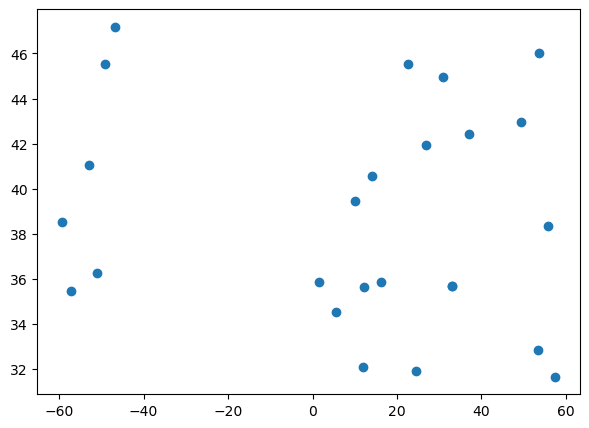

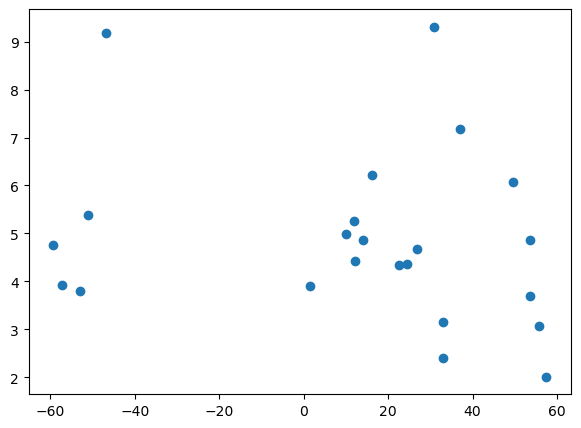

In [51]:
fig,ax = plt.subplots(figsize=(7,5))
ax.scatter(latitudes, evolution.peak_wavelength)

fig,ax = plt.subplots(figsize=(7,5))
ax.scatter(latitudes, evolution.peak_width)

In [52]:
ds_seg_peaks = ds_segments_expert_it.sel(segment=evolution.dropna('segment').segment)#.sortby('lat_mean')
latitudes = ds_seg_peaks.where((ds_seg_peaks.lat_mean>=-2)&(ds_seg_peaks.lat_mean<=15),drop=True).lat_mean.values

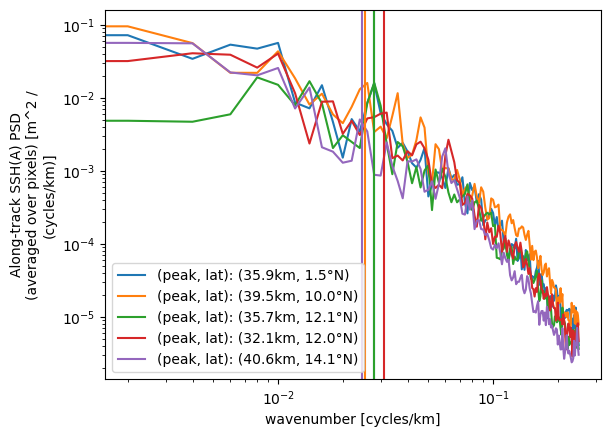

In [53]:
sc = ds_seg_peaks.where((ds_seg_peaks.lat_mean>=-2)&(ds_seg_peaks.lat_mean<=15),drop=True).psd.plot(xscale='log',
                                                                                                    yscale='log',
                                                                                                    hue='segment',)
lc = evolution.dropna('segment').where((ds_seg_peaks.lat_mean>=-2)&(ds_seg_peaks.lat_mean<=15),drop=True).peak_wavelength
for c,l in zip(sc,lc):
    plt.axvline(1/l,c=c.get_color())
plt.legend([f"(peak, lat): ({l:.1f}km, {latitudes[i]:.1f}°N)" for i,l in enumerate(lc.values)])

In [54]:
ds_seg_peaks.where((ds_seg_peaks.lat_mean>=-2)&(ds_seg_peaks.lat_mean<=15),drop=True).swath

<xarray.DataArray 'swath' (segment: 5)> Size: 40B
array(['left', 'left', 'left', 'right', 'right'], dtype=object)
Coordinates:
  * segment  (segment) int64 40B 14 18 19 62 63